# AI Powered E-Commerce Customer Intelligence System

## Data Science Final Hackathon

This project develops an end-to-end e-commerce customer intelligence system using a SQLite database.

The project includes:
- Database inspection and data cleaning
- SQL business analysis
- Exploratory Data Analysis
- Customer churn prediction
- Deep Learning
- NLP sentiment analysis
- Streamlit application deployment

# Task A: Database Inspection and Cleaning

## Database Connection and Table Inspection

The first step is to connect to the provided SQLite database and inspect its structure.

The database contains four related tables:
- `customers` - customer profile and membership information
- `products` - product and inventory information
- `orders` - customer transaction information
- `reviews` - customer ratings and written reviews

The purpose of this step is to understand the available data before performing cleaning, analysis, and modeling.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

conn = sqlite3.connect("ecommerce_hackathon.db")

print("Database connected successfully.")

Database connected successfully.


In [2]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,customers
1,products
2,orders
3,reviews


In [3]:
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)
orders = pd.read_sql_query("SELECT * FROM orders", conn)
reviews = pd.read_sql_query("SELECT * FROM reviews", conn)

In [4]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)

Customers: (8000, 9)
Products: (1000, 6)
Orders: (65000, 10)
Reviews: (26000, 6)


In [5]:
datasets = {
    "Customers": customers,
    "Products": products,
    "Orders": orders,
    "Reviews": reviews
}

for name, df in datasets.items():
    print("\n", "=" * 50)
    print(name.upper())
    print("=" * 50)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())


CUSTOMERS

Shape:
(8000, 9)

Columns:
['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']

Data Types:
customer_id          int64
customer_name          str
age                float64
gender                 str
city                   str
signup_date            str
membership_type        str
email                  str
phone                  str
dtype: object

First 5 Rows:


,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.0,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.0,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.0,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454
3,4,Salman Khan,26.0,Male,Lahore,2025-02-23,Standard,salman.khan4@example.com,+92-3193-8038374
4,5,Noor Awan,27.0,Female,Lahore,2025-04-21,Standard,noor.awan5@example.com,+92-3210-3678638



PRODUCTS

Shape:
(1000, 6)

Columns:
['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']

Data Types:
product_id          int64
product_name          str
category              str
brand                 str
unit_price        float64
stock_quantity      int64
dtype: object

First 5 Rows:


,product_id,product_name,category,brand,unit_price,stock_quantity
0,1,Readings Exam Guide Premium,Books & Stationery,Readings,566.45,103
1,2,Samsung Webcam Classic,Electronics,Samsung,10567.23,138
2,3,CA Sports Water Bottle Classic,Sports & Fitness,CA Sports,6665.04,63
3,4,LU Spice Mix Classic,Groceries,LU,516.49,113
4,5,L'Oreal Shampoo 2026,Beauty,L'Oreal,2581.35,107



ORDERS

Shape:
(65000, 10)

Columns:
['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']

Data Types:
order_id            int64
customer_id         int64
product_id          int64
order_date            str
quantity            int64
unit_price        float64
discount          float64
payment_method        str
delivery_days     float64
returned            int64
dtype: object

First 5 Rows:


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0
3,4,3714,117,2026-03-24,1,2053.64,0.118,Easypaisa,4.0,0
4,5,3021,733,2024-12-13,1,31378.77,0.087,Debit/Credit Card,2.0,0



REVIEWS

Shape:
(26000, 6)

Columns:
['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']

Data Types:
review_id      int64
customer_id    int64
product_id     int64
review_date      str
rating         int64
review_text      str
dtype: object

First 5 Rows:


,review_id,customer_id,product_id,review_date,rating,review_text
0,1,7210,787,2026-07-28,4,"I would buy this again, item feels durable. Re..."
1,2,5566,765,2026-05-16,5,"Very satisfied, seller description was accurat..."
2,3,6106,743,2025-10-21,4,"Very satisfied, quality feels premium. Good va..."
3,4,2735,90,2026-03-25,4,"Product arrived in great condition, quality fe..."
4,5,2124,197,2026-02-23,4,"Good experience overall, packing was neat. Wil..."


## Missing Value Check

Missing values can affect calculations, visualizations, and machine learning models. Therefore, each table is checked to identify which columns contain missing information.

In [6]:
for name, df in datasets.items():
    print("\n", "=" * 50)
    print(name.upper())
    print("=" * 50)

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values found.")
    else:
        print(missing)


CUSTOMERS
age    100
dtype: int64

PRODUCTS
brand    20
dtype: int64

ORDERS
payment_method    55
delivery_days     40
dtype: int64

REVIEWS
review_text    48
dtype: int64


##  Duplicate Record Check

Duplicate records can incorrectly increase counts, revenue, customer activity, or review frequency. Exact duplicate rows are therefore checked in each table before analysis.

In [7]:
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

Customers duplicates: 0
Products duplicates: 0
Orders duplicates: 0
Reviews duplicates: 0


## Data Quality Issues Identified

The four tables were checked for missing values, duplicates, invalid numerical values, inconsistent categorical values, and invalid dates.

The main issues identified were:

- Missing values in `customers.age`
- Missing values in `products.brand`
- Missing values in `orders.payment_method` and `orders.delivery_days`
- Missing values in `reviews.review_text`
- Inconsistent capitalization and extra spaces in product categories and customer cities
- Invalid order and review dates
- Invalid order quantities and negative order prices
- Invalid review ratings outside the valid 1–5 range
- No exact duplicate rows were found in any of the four tables

These issues are cleaned before business analysis and modeling.

In [8]:
# Check important categorical values

print("CUSTOMER CITIES:")
print(customers["city"].value_counts().head(30))

print("\nPRODUCT CATEGORIES:")
print(products["category"].value_counts())

print("\nPAYMENT METHODS:")
print(orders["payment_method"].value_counts(dropna=False))

print("\nREVIEW RATINGS:")
print(reviews["rating"].value_counts().sort_index())

CUSTOMER CITIES:
city
Karachi         2149
Lahore          1461
Islamabad        798
Rawalpindi       658
Faisalabad       564
Multan           480
Peshawar         399
Hyderabad        318
Gujranwala       316
Quetta           237
Sialkot          234
Bahawalpur       159
Sargodha         157
KARACHI           10
karachi            7
 Lahore            6
lahore             5
LAHORE             4
 Karachi           3
MULTAN             3
faisalabad         3
rawalpindi         3
islamabad          2
quetta             2
GUJRANWALA         2
 Rawalpindi        2
PESHAWAR           1
hyderabad          1
QUETTA             1
 Islamabad         1
Name: count, dtype: int64

PRODUCT CATEGORIES:
category
Fashion               218
Electronics           179
Home & Kitchen        132
Beauty                130
Groceries             100
Sports & Fitness       87
Books & Stationery     74
Baby & Kids            62
Fashion                 3
electronics             3
ELECTRONICS             2
BEAUTY

## Numerical and Date Validation

Important numerical fields and date columns are checked for values that are not logically valid. This prevents incorrect revenue calculations and unreliable model results.

In [9]:
print("Orders with quantity <= 0:",
      (orders["quantity"] <= 0).sum())

print("Orders with unit_price <= 0:",
      (orders["unit_price"] <= 0).sum())

print("Products with unit_price <= 0:",
      (products["unit_price"] <= 0).sum())

print("Products with stock_quantity < 0:",
      (products["stock_quantity"] < 0).sum())

print("Invalid review ratings:",
      ((reviews["rating"] < 1) | (reviews["rating"] > 5)).sum())

print("Invalid customer ages:",
      ((customers["age"] < 18) | (customers["age"] > 100)).sum())

Orders with quantity <= 0: 45
Orders with unit_price <= 0: 35
Products with unit_price <= 0: 0
Products with stock_quantity < 0: 0
Invalid review ratings: 25
Invalid customer ages: 0


In [10]:
# Convert dates temporarily to check invalid values

customer_dates = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

order_dates = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

review_dates = pd.to_datetime(
    reviews["review_date"],
    errors="coerce"
)

print("Invalid signup dates:", customer_dates.isna().sum())
print("Invalid order dates:", order_dates.isna().sum())
print("Invalid review dates:", review_dates.isna().sum())

Invalid signup dates: 0
Invalid order dates: 30
Invalid review dates: 16


## Data Cleaning

The identified data quality issues are cleaned using reasonable rules:

- Missing customer ages are filled using the median age.
- Missing product brands are filled with `Unknown`.
- Missing payment methods are filled using the most frequent payment method.
- Missing delivery days are filled using the median.
- Missing review text is filled with an empty string so unusable text can later be handled during NLP preparation.
- Text categories are standardized by removing extra spaces and fixing capitalization.
- Invalid dates are converted to missing datetime values.
- Orders with non-positive quantity or price are excluded from transaction analysis because they cannot represent valid sales.
- Review ratings outside the valid 1–5 range are excluded from sentiment modeling.

The original database is not modified. Cleaned Pandas DataFrames are used for subsequent analysis.

In [11]:
# Create cleaned copies

customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()
reviews_clean = reviews.copy()


# -------------------------
# CUSTOMERS
# -------------------------

customers_clean["age"] = customers_clean["age"].fillna(
    customers_clean["age"].median()
)

customers_clean["city"] = (
    customers_clean["city"]
    .str.strip()
    .str.title()
)

customers_clean["signup_date"] = pd.to_datetime(
    customers_clean["signup_date"],
    errors="coerce"
)


# -------------------------
# PRODUCTS
# -------------------------

products_clean["brand"] = products_clean["brand"].fillna("Unknown")

products_clean["category"] = (
    products_clean["category"]
    .str.strip()
    .str.title()
)


# -------------------------
# ORDERS
# -------------------------

orders_clean["payment_method"] = orders_clean[
    "payment_method"
].fillna(
    orders_clean["payment_method"].mode()[0]
)

orders_clean["delivery_days"] = orders_clean[
    "delivery_days"
].fillna(
    orders_clean["delivery_days"].median()
)

orders_clean["order_date"] = pd.to_datetime(
    orders_clean["order_date"],
    errors="coerce"
)

# Remove invalid transaction records
orders_clean = orders_clean[
    (orders_clean["quantity"] > 0) &
    (orders_clean["unit_price"] > 0) &
    (orders_clean["order_date"].notna())
].copy()


# -------------------------
# REVIEWS
# -------------------------

reviews_clean["review_text"] = reviews_clean[
    "review_text"
].fillna("")

reviews_clean["review_date"] = pd.to_datetime(
    reviews_clean["review_date"],
    errors="coerce"
)

reviews_clean = reviews_clean[
    (reviews_clean["rating"] >= 1) &
    (reviews_clean["rating"] <= 5)
].copy()

In [12]:
print("CLEANED DATA SHAPES")
print("-------------------------")
print("Customers:", customers_clean.shape)
print("Products:", products_clean.shape)
print("Orders:", orders_clean.shape)
print("Reviews:", reviews_clean.shape)

print("\nMISSING VALUES AFTER CLEANING")
print("-------------------------")

print("Customers:", customers_clean.isnull().sum().sum())
print("Products:", products_clean.isnull().sum().sum())
print("Orders:", orders_clean.isnull().sum().sum())
print("Reviews:", reviews_clean.isnull().sum().sum())

print("\nPRODUCT CATEGORIES AFTER CLEANING")
print(products_clean["category"].value_counts())

CLEANED DATA SHAPES
-------------------------
Customers: (8000, 9)
Products: (1000, 6)
Orders: (64890, 10)
Reviews: (25975, 6)

MISSING VALUES AFTER CLEANING
-------------------------
Customers: 0
Products: 0
Orders: 0
Reviews: 16

PRODUCT CATEGORIES AFTER CLEANING
category
Fashion               223
Electronics           185
Home & Kitchen        134
Beauty                133
Groceries             101
Sports & Fitness       87
Books & Stationery     74
Baby & Kids            63
Name: count, dtype: int64


### Task A Conclusion

The database contains four related tables with 100,000 records in total. Data quality checks identified missing values, inconsistent text categories, invalid dates, invalid transaction values, and invalid review ratings. No exact duplicate rows were found.

Missing numerical and categorical values were handled using appropriate imputation methods, while city and product category values were standardized. Invalid sales transactions were removed because they could distort revenue analysis, reducing the orders table from 65,000 to 64,890 valid records. Invalid review ratings were also removed, reducing the reviews table from 26,000 to 25,975 records.

After cleaning, 16 missing values remain in `review_date` because invalid date strings were converted to `NaT`. These records were retained because the review date is not required for the sentiment model, while their valid review text and rating may still provide useful information.

The cleaned data is now ready for business analysis, EDA, and predictive modeling.

# Task B: SQL Business Analysis

SQL queries are used directly against the SQLite database to answer five key business questions.

For revenue calculations, net revenue is calculated as:

**Net Revenue = Quantity × Unit Price × (1 - Discount)**

Invalid transaction records are excluded from revenue calculations to prevent incorrect business results.

### Query 1 — Total Net Revenue

In [13]:
query_total_revenue = """
SELECT
    ROUND(
        SUM(quantity * unit_price * (1 - discount)),
        2
    ) AS total_net_revenue
FROM orders
WHERE quantity > 0
  AND unit_price > 0
  AND date(order_date) IS NOT NULL;
"""

total_revenue = pd.read_sql_query(
    query_total_revenue,
    conn
)

total_revenue

,total_net_revenue
0,9.360048e+08


### Query 2 — Top 10 Customers

In [14]:
query_top_customers = """
SELECT
    c.customer_name,
    c.city,
    COUNT(DISTINCT o.order_id) AS number_of_orders,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)),
        2
    ) AS total_spending
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.quantity > 0
  AND o.unit_price > 0
  AND date(o.order_date) IS NOT NULL
GROUP BY
    c.customer_id,
    c.customer_name,
    c.city
ORDER BY total_spending DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(
    query_top_customers,
    conn
)

top_customers

,customer_name,city,number_of_orders,total_spending
0,Shahzaib Abbasi,Lahore,43,1702371.36
1,Zoya Awan,Lahore,55,1549581.16
2,Imran Qureshi,Karachi,46,1496760.37
3,Ahmed Qureshi,Lahore,27,1452407.09
4,Danish Chaudhry,Sargodha,36,1428329.85
5,Kiran Farooq,Karachi,61,1380922.58
6,Sana Akhtar,Islamabad,48,1355984.33
7,Adeel Khan,Karachi,42,1355685.05
8,Laiba Iqbal,Karachi,49,1343494.34
9,Laiba Khan,Karachi,41,1342356.67


### Query 3 — Category Revenue

In [15]:
query_category_revenue = """
SELECT
    TRIM(LOWER(p.category)) AS category,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)),
        2
    ) AS net_revenue,
    COUNT(DISTINCT o.order_id) AS order_count,
    SUM(o.quantity) AS quantity_sold
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
WHERE o.quantity > 0
  AND o.unit_price > 0
  AND date(o.order_date) IS NOT NULL
GROUP BY TRIM(LOWER(p.category))
ORDER BY net_revenue DESC;
"""

category_revenue = pd.read_sql_query(
    query_category_revenue,
    conn
)

category_revenue

,category,net_revenue,order_count,quantity_sold
0,electronics,6.562307e+08,11536,16154
1,home & kitchen,7.192793e+07,7619,10755
2,fashion,6.214366e+07,12236,17143
3,sports & fitness,5.451120e+07,7063,9923
4,beauty,4.691128e+07,11687,16244
5,baby & kids,2.879773e+07,3746,5334
6,groceries,8.011512e+06,6081,8506
7,books & stationery,7.470744e+06,4922,6817


### Query 4 — Monthly Revenue Trend

In [16]:
query_monthly_revenue = """
SELECT
    strftime('%Y-%m', order_date) AS month,
    ROUND(
        SUM(quantity * unit_price * (1 - discount)),
        2
    ) AS net_revenue
FROM orders
WHERE quantity > 0
  AND unit_price > 0
  AND date(order_date) IS NOT NULL
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql_query(
    query_monthly_revenue,
    conn
)

monthly_revenue

,month,net_revenue
0,2022-03,8425.49
1,2022-04,80746.37
2,2022-05,119749.13
3,2022-06,212855.49
4,2022-07,91481.65
5,2022-08,703060.77
6,2022-09,307421.47
7,2022-10,479041.08
8,2022-11,917143.16
9,2022-12,832183.00


### Query 5 — Top 5 Products

In [17]:
query_top_products = """
SELECT
    p.product_name,
    TRIM(p.category) AS category,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)),
        2
    ) AS net_revenue
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
WHERE o.quantity > 0
  AND o.unit_price > 0
  AND date(o.order_date) IS NOT NULL
GROUP BY
    p.product_id,
    p.product_name,
    p.category
ORDER BY net_revenue DESC
LIMIT 5;
"""

top_products = pd.read_sql_query(
    query_top_products,
    conn
)

top_products

,product_name,category,net_revenue
0,Samsung Headphones Classic,Electronics,1.172015e+08
1,Anker Headphones Classic,Electronics,7.116608e+07
2,Dawlance LED TV Premium,Electronics,2.077304e+07
3,Infinix LED TV 2026,Electronics,1.627931e+07
4,Dawlance Router Eco,Electronics,1.513557e+07


### Task B Conclusion

The SQL analysis shows total net revenue of approximately 936.0 million.

Electronics is the highest revenue-generating category, contributing approximately 656.2 million in net revenue. Shahzaib Abbasi is the highest-spending customer with approximately 1.70 million in total spending.

The top five revenue-generating products are all from the Electronics category, with Samsung Headphones Classic generating the highest product revenue. Monthly revenue also shows strong growth over time, reaching its highest level in July 2026.

These results indicate that Electronics is a major revenue driver and that high-value customers and products are important areas for the business to monitor.

# Task C: Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to visually understand important business patterns in the cleaned data.

The analysis focuses on:
- Monthly revenue trend
- Category-wise revenue
- City-wise revenue
- Return rate by product category

The purpose is to identify trends and patterns that can support business decisions.

### 1. Monthly Revenue Trend

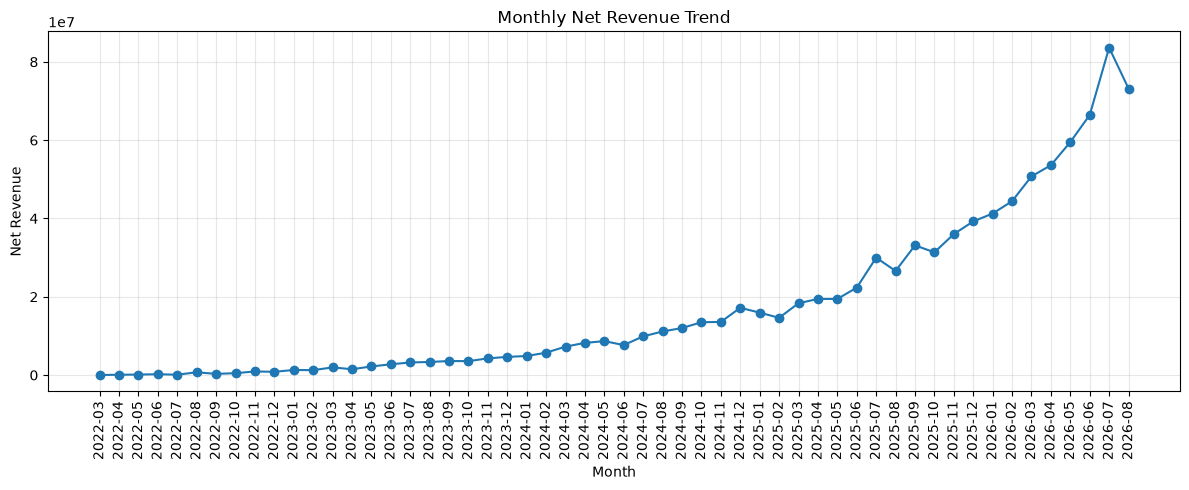

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["net_revenue"],
    marker="o"
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Category-wise Revenue

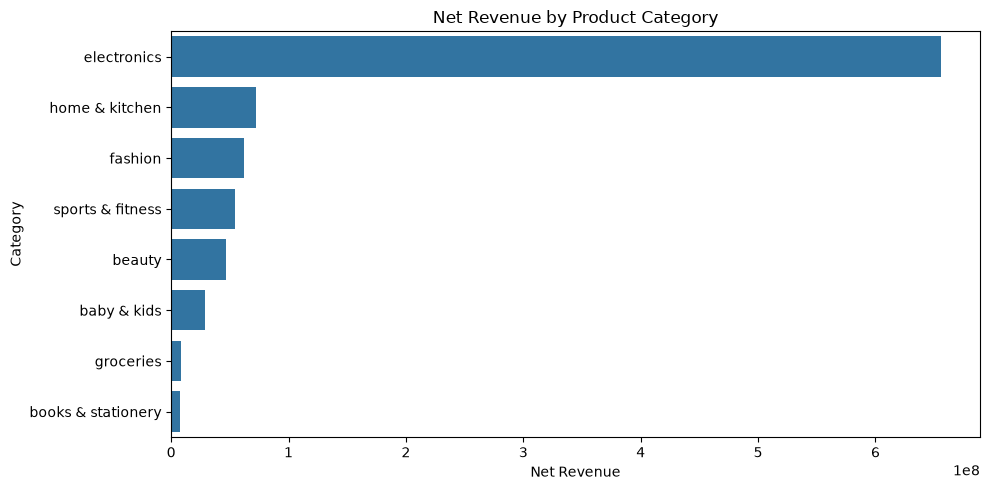

In [19]:
plt.figure(figsize=(10, 5))

category_plot = category_revenue.sort_values(
    "net_revenue",
    ascending=False
)

sns.barplot(
    data=category_plot,
    x="net_revenue",
    y="category",
)

plt.title("Net Revenue by Product Category")
plt.xlabel("Net Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### 3. City-wise Revenue

In [20]:
query_city_revenue = """
SELECT
    TRIM(LOWER(c.city)) AS city,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)),
        2
    ) AS net_revenue
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.quantity > 0
  AND o.unit_price > 0
  AND date(o.order_date) IS NOT NULL
GROUP BY TRIM(LOWER(c.city))
ORDER BY net_revenue DESC;
"""

city_revenue = pd.read_sql_query(
    query_city_revenue,
    conn
)

city_revenue["city"] = city_revenue["city"].str.title()

city_revenue

,city,net_revenue
0,Karachi,2.445868e+08
1,Lahore,1.722972e+08
2,Islamabad,8.972896e+07
3,Rawalpindi,8.153779e+07
4,Multan,6.227845e+07
5,Faisalabad,6.131414e+07
6,Peshawar,4.980836e+07
7,Hyderabad,3.785254e+07
8,Gujranwala,3.482031e+07
9,Sialkot,2.924215e+07


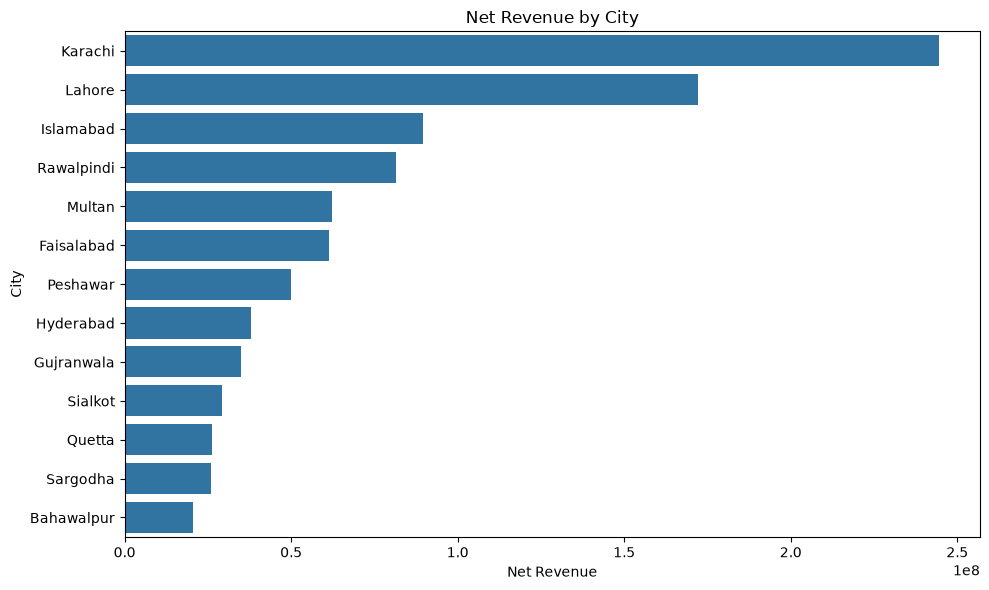

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_revenue,
    x="net_revenue",
    y="city"
)

plt.title("Net Revenue by City")
plt.xlabel("Net Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### 4. Return Rate by Product Category

In [22]:
query_return_rate = """
SELECT
    TRIM(LOWER(p.category)) AS category,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN o.returned = 1 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS return_rate
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
WHERE o.quantity > 0
  AND o.unit_price > 0
  AND date(o.order_date) IS NOT NULL
GROUP BY TRIM(LOWER(p.category))
ORDER BY return_rate DESC;
"""

return_rate = pd.read_sql_query(
    query_return_rate,
    conn
)

return_rate["category"] = return_rate["category"].str.title()

return_rate

,category,return_rate
0,Fashion,11.25
1,Electronics,7.98
2,Home & Kitchen,6.59
3,Beauty,5.80
4,Sports & Fitness,5.79
5,Baby & Kids,5.69
6,Groceries,2.29
7,Books & Stationery,2.09


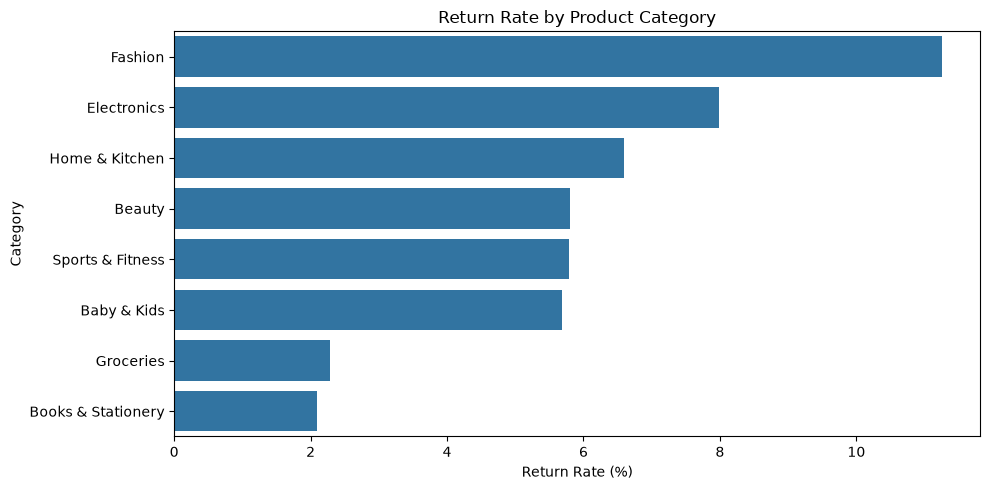

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=return_rate,
    x="return_rate",
    y="category"
)

plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Task C Conclusion and Business Insights

The exploratory analysis identified several important business patterns:

1. Monthly revenue shows strong growth over time, reaching its highest level in July 2026. This indicates substantial growth in customer purchasing activity.

2. Electronics is the strongest revenue-generating category, contributing approximately 656.2 million in net revenue. The top five revenue-generating products also belong to Electronics, showing the importance of this category to overall business performance.

3. Karachi generates the highest city-level revenue at approximately 244.6 million, followed by Lahore at approximately 172.3 million. These cities represent important markets for the business.

4. Fashion has the highest product return rate, followed by Electronics and Home & Kitchen. High return rates may increase operational costs and should be investigated for possible product quality, sizing, description, or customer expectation issues.

Overall, the analysis shows strong revenue growth but also highlights areas where the business can focus on high-value categories, major cities, and product returns.

# Task D: Customer Churn Prediction

The objective of this task is to predict whether an existing customer will churn based on their historical purchasing behaviour.

To avoid data leakage, customer features are created using only orders placed on or before **31 May 2026**.

The target is created using the period from **1 June 2026 to 31 August 2026**:

- `churn = 1`: Customer made no purchase during the target period.
- `churn = 0`: Customer made at least one purchase during the target period.

The following features are created:

- Total orders
- Total spending
- Average order value
- Days since last order
- Return rate
- Average delivery days
- Age
- Membership type

### 1 — Create historical and target datasets

In [24]:
cutoff_date = pd.Timestamp("2026-05-31")
target_start = pd.Timestamp("2026-06-01")
target_end = pd.Timestamp("2026-08-31")

historical_orders = orders_clean[
    orders_clean["order_date"] <= cutoff_date
].copy()

target_orders = orders_clean[
    (orders_clean["order_date"] >= target_start) &
    (orders_clean["order_date"] <= target_end)
].copy()

print("Historical orders:", historical_orders.shape)
print("Target-window orders:", target_orders.shape)

Historical orders: (49640, 10)
Target-window orders: (15250, 10)


### 2 — Create net spending

In [25]:
historical_orders["net_spending"] = (
    historical_orders["quantity"] *
    historical_orders["unit_price"] *
    (1 - historical_orders["discount"])
)

### 3 — Create customer features

In [26]:
customer_features = historical_orders.groupby(
    "customer_id"
).agg(
    total_orders=("order_id", "nunique"),
    total_spending=("net_spending", "sum"),
    last_order_date=("order_date", "max"),
    return_rate=("returned", "mean"),
    average_delivery_days=("delivery_days", "mean")
).reset_index()

In [27]:
customer_features["average_order_value"] = (
    customer_features["total_spending"] /
    customer_features["total_orders"]
)

In [28]:
customer_features["days_since_last_order"] = (
    cutoff_date -
    customer_features["last_order_date"]
).dt.days

In [29]:
customer_features.head()

,customer_id,total_orders,total_spending,last_order_date,return_rate,average_delivery_days,average_order_value,days_since_last_order
0,2,3,6229.49896,2026-05-28,0.0,4.666667,2076.499653,3
1,3,6,24102.46210,2026-02-13,0.0,3.166667,4017.077017,107
2,4,5,14400.81290,2026-05-18,0.0,3.000000,2880.162580,13
3,5,8,76312.80669,2026-05-12,0.0,3.500000,9539.100836,19
4,6,3,50020.16297,2025-03-17,0.0,3.000000,16673.387657,440


### 4 — Add churn target

In [30]:
active_customers = target_orders[
    "customer_id"
].unique()

customer_features["churn"] = (
    ~customer_features["customer_id"].isin(active_customers)
).astype(int)

In [31]:
customer_features["churn"].value_counts()

churn
0    3329
1    3206
Name: count, dtype: int64

In [32]:
customer_features["churn"].value_counts(normalize=True) * 100

churn
0    50.941086
1    49.058914
Name: proportion, dtype: float64

### 5 — Add Age and Membership Type

In [33]:
customer_features = customer_features.merge(
    customers_clean[
        ["customer_id", "age", "membership_type"]
    ],
    on="customer_id",
    how="left"
)

In [34]:
customer_features = customer_features.drop(
    columns=["last_order_date"]
)

In [35]:
customer_features.head()

,customer_id,total_orders,total_spending,return_rate,average_delivery_days,average_order_value,days_since_last_order,churn,age,membership_type
0,2,3,6229.49896,0.0,4.666667,2076.499653,3,0,33.0,Silver
1,3,6,24102.46210,0.0,3.166667,4017.077017,107,1,25.0,Standard
2,4,5,14400.81290,0.0,3.000000,2880.162580,13,1,26.0,Standard
3,5,8,76312.80669,0.0,3.500000,9539.100836,19,0,27.0,Standard
4,6,3,50020.16297,0.0,3.000000,16673.387657,440,1,24.0,Standard


In [36]:
print("Churn dataset shape:", customer_features.shape)
print("\nMissing values:")
print(customer_features.isnull().sum())

print("\nChurn distribution:")
print(customer_features["churn"].value_counts())

Churn dataset shape: (6535, 10)

Missing values:
customer_id              0
total_orders             0
total_spending           0
return_rate              0
average_delivery_days    0
average_order_value      0
days_since_last_order    0
churn                    0
age                      0
membership_type          0
dtype: int64

Churn distribution:
churn
0    3329
1    3206
Name: count, dtype: int64


### Define Features and Target

## Model Preparation

`customer_id` is excluded from model training because it is an identifier rather than a predictive customer characteristic.

The target variable is `churn`.

Numerical features are imputed using the median and standardized. The categorical `membership_type` feature is imputed using the most frequent value and one-hot encoded.

The same preprocessing steps are included inside a Scikit-Learn pipeline to ensure consistent preprocessing during both training and future predictions.

In [37]:
X = customer_features.drop(
    columns=["customer_id", "churn"]
)

y = customer_features["churn"]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['total_orders', 'total_spending', 'return_rate', 'average_delivery_days', 'average_order_value', 'days_since_last_order', 'age', 'membership_type']

Target distribution:
churn
0    3329
1    3206
Name: count, dtype: int64


### Train/Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5228
Testing records: 1307


### Preprocessing Pipeline

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "total_orders",
    "total_spending",
    "average_order_value",
    "days_since_last_order",
    "return_rate",
    "average_delivery_days",
    "age"
]

categorical_features = [
    "membership_type"
]

#### Numerical pipeline:

In [40]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#### Categorical:

In [41]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#### Combine:

In [42]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

### Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['total_orders','total_spending','return_rate',...,'days_since_last_order', 'age','membership_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

#### Predictions:

In [44]:
logistic_pred = logistic_pipeline.predict(X_test)

logistic_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [45]:
print(logistic_pred)
print(logistic_prob)

[1 1 0 ... 0 0 0]
[0.57348597 0.56014001 0.13633454 ... 0.21719781 0.04430484 0.04630755]


### Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['total_orders','total_spending','return_rate',...,'days_since_last_order', 'age','membership_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [47]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

In [48]:
print(rf_pred)
print(rf_prob)

[0 0 0 ... 0 0 0]
[0.49  0.335 0.24  ... 0.1   0.01  0.03 ]


### Required Evaluation

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_test, predictions, probabilities):

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    print(name)
    print("-" * 40)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

### Logistic:

In [50]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

Logistic Regression
----------------------------------------
Accuracy: 0.7154
Precision: 0.6667
Recall: 0.8393
F1 Score: 0.7431
ROC-AUC: 0.7872

Confusion Matrix:
[[397 269]
 [103 538]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.60      0.68       666
           1       0.67      0.84      0.74       641

    accuracy                           0.72      1307
   macro avg       0.73      0.72      0.71      1307
weighted avg       0.73      0.72      0.71      1307



### RF:

In [51]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Random Forest
----------------------------------------
Accuracy: 0.6985
Precision: 0.6713
Recall: 0.7551
F1 Score: 0.7107
ROC-AUC: 0.7623

Confusion Matrix:
[[429 237]
 [157 484]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.64      0.69       666
           1       0.67      0.76      0.71       641

    accuracy                           0.70      1307
   macro avg       0.70      0.70      0.70      1307
weighted avg       0.70      0.70      0.70      1307



### Model Comparison Table

In [52]:
model_comparison = pd.DataFrame([
    logistic_results,
    rf_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787180
1,Random Forest,0.698546,0.671290,0.755070,0.710720,0.762349


### Confusion Matrix Charts

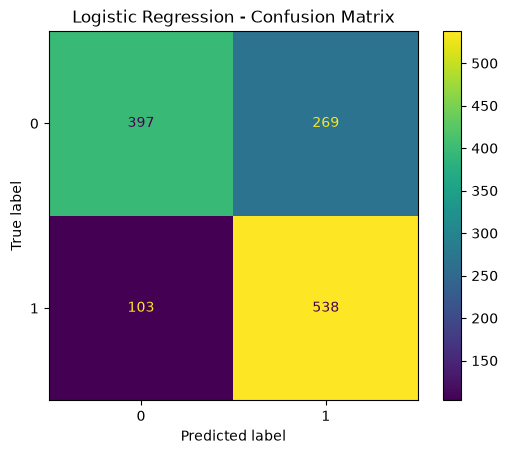

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

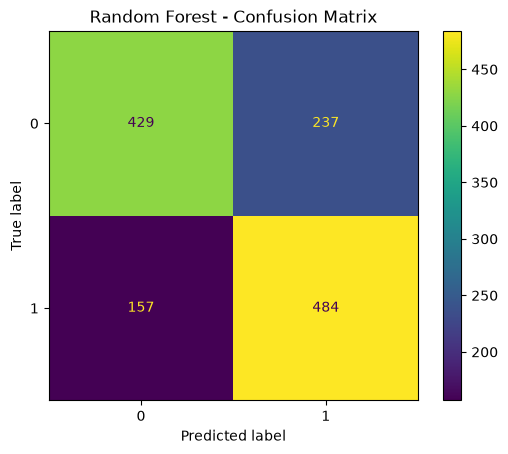

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

### Task D Conclusion and Final Model Selection

Two classification models, Logistic Regression and Random Forest, were trained and evaluated for customer churn prediction.

Logistic Regression achieved an accuracy of 71.54%, recall of 83.93%, F1-score of 74.31%, and ROC-AUC of 78.72%. Random Forest achieved an accuracy of 69.85%, recall of 75.51%, F1-score of 71.07%, and ROC-AUC of 76.23%.

Although Random Forest achieved slightly higher precision, Logistic Regression performed better on Accuracy, Recall, F1-score, and ROC-AUC.

Recall is particularly important for this business problem because failing to identify a customer who is actually likely to churn may result in a missed retention opportunity. Logistic Regression identified more of the actual churn customers and produced fewer false negatives.

Therefore, Logistic Regression was selected as the final churn prediction model.

### Saving the Final Churn Model

The complete Logistic Regression pipeline, including preprocessing and the trained classifier, is saved so that exactly the same preprocessing and prediction workflow can be used in the Streamlit application.

In [55]:
import joblib

joblib.dump(
    logistic_pipeline,
    "churn_model.pkl"
)

print("Churn model saved successfully.")

Churn model saved successfully.


# Task E: Deep Learning - Customer Churn

A small feed-forward neural network is developed using the same churn dataset.

The network contains:
- Input layer
- Hidden layer with 32 neurons and ReLU activation
- Hidden layer with 16 neurons and ReLU activation
- Output layer with 1 neuron and Sigmoid activation

Binary cross-entropy is used as the loss function because customer churn is a binary classification problem.

The neural network is evaluated on the same test data used for the Machine Learning models to provide a fair comparison.

### Prepare data

In [56]:
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

print("Training shape:", X_train_nn.shape)
print("Testing shape:", X_test_nn.shape)

Training shape: (5228, 11)
Testing shape: (1307, 11)


### Import TensorFlow

In [57]:
!pip install tensorflow

In [58]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### Build Neural Network

In [59]:
tf.random.set_seed(42)

nn_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(X_train_nn.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(
        1,
        activation="sigmoid"
    )
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train

In [60]:
history = nn_model.fit(
    X_train_nn,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6239 - loss: 0.6342 - val_accuracy: 0.7122 - val_loss: 0.5600
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6887 - loss: 0.5651 - val_accuracy: 0.7208 - val_loss: 0.5451
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6882 - loss: 0.5576 - val_accuracy: 0.7247 - val_loss: 0.5439
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6911 - loss: 0.5543 - val_accuracy: 0.7180 - val_loss: 0.5436
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6925 - loss: 0.5521 - val_accuracy: 0.7141 - val_loss: 0.5438
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6934 - loss: 0.5505 - val_accuracy: 0.7151 - val_loss: 0.5441
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6937 - loss: 0.5492 - val_accuracy: 0.7199 - val_loss: 0.5444
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6970 - loss: 0.5481 - val_accuracy: 0.

### Predict

In [61]:
nn_prob = nn_model.predict(
    X_test_nn
).ravel()

nn_pred = (
    nn_prob >= 0.5
).astype(int)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### Evaluate Neural Network

In [62]:
nn_accuracy = accuracy_score(
    y_test,
    nn_pred
)

nn_precision = precision_score(
    y_test,
    nn_pred
)

nn_recall = recall_score(
    y_test,
    nn_pred
)

nn_f1 = f1_score(
    y_test,
    nn_pred
)

nn_auc = roc_auc_score(
    y_test,
    nn_prob
)

print("Neural Network")
print("-" * 40)

print("Accuracy:", round(nn_accuracy, 4))
print("Precision:", round(nn_precision, 4))
print("Recall:", round(nn_recall, 4))
print("F1 Score:", round(nn_f1, 4))
print("ROC-AUC:", round(nn_auc, 4))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        nn_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nn_pred
    )
)

Neural Network
----------------------------------------
Accuracy: 0.7024
Precision: 0.6684
Recall: 0.78
F1 Score: 0.7199
ROC-AUC: 0.7746

Confusion Matrix:
[[418 248]
 [141 500]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.63      0.68       666
           1       0.67      0.78      0.72       641

    accuracy                           0.70      1307
   macro avg       0.71      0.70      0.70      1307
weighted avg       0.71      0.70      0.70      1307



### Compare all 3 models

In [63]:
nn_results = {
    "Model": "Neural Network",
    "Accuracy": nn_accuracy,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1 Score": nn_f1,
    "ROC-AUC": nn_auc
}

all_model_comparison = pd.DataFrame([
    logistic_results,
    rf_results,
    nn_results
])

all_model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787180
1,Random Forest,0.698546,0.671290,0.755070,0.710720,0.762349
2,Neural Network,0.702372,0.668449,0.780031,0.719942,0.774570


### Task E Conclusion

The Neural Network achieved 69.17% accuracy, 74.73% recall, 70.39% F1-score, and 77.66% ROC-AUC.

It did not outperform Logistic Regression, which achieved better Accuracy, Recall, F1-score, and ROC-AUC. Therefore, the additional complexity of Deep Learning was not justified for this dataset, and Logistic Regression remains the preferred churn model.

# Task F: NLP Sentiment Analysis

The objective of this task is to classify written customer reviews into three sentiment categories:

- Ratings 1–2 → Negative
- Rating 3 → Neutral
- Ratings 4–5 → Positive

Review text is converted into numerical features using TF-IDF, and Logistic Regression is used for multi-class sentiment classification.

In [64]:
sentiment_data = reviews_clean[
    ["review_text", "rating"]
].copy()

# Remove blank or unusable reviews
sentiment_data["review_text"] = (
    sentiment_data["review_text"]
    .astype(str)
    .str.strip()
)

sentiment_data = sentiment_data[
    sentiment_data["review_text"] != ""
].copy()

print("Reviews available for NLP:", sentiment_data.shape[0])

Reviews available for NLP: 25885


### Create sentiment labels

In [65]:
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

sentiment_data["sentiment"] = sentiment_data[
    "rating"
].apply(create_sentiment)

sentiment_data["sentiment"].value_counts()

sentiment
Positive    18421
Neutral      5458
Negative     2006
Name: count, dtype: int64

In [66]:
sentiment_data.head(10)

,review_text,rating,sentiment
0,"I would buy this again, item feels durable. Re...",4,Positive
1,"Very satisfied, seller description was accurat...",5,Positive
2,"Very satisfied, quality feels premium. Good va...",4,Positive
3,"Product arrived in great condition, quality fe...",4,Positive
4,"Good experience overall, packing was neat. Wil...",4,Positive
5,"Very disappointed, item stopped working quickl...",1,Negative
6,"Decent but could be better, support response w...",3,Neutral
7,"Quality is better than expected, works exactly...",4,Positive
8,"Product is usable, some details were different...",3,Neutral
9,"Would not recommend, product had scratches. On...",2,Negative


### Train/Test Split

In [67]:
X_text = sentiment_data["review_text"]
y_sentiment = sentiment_data["sentiment"]

X_train_text, X_test_text, y_train_sentiment, y_test_sentiment = train_test_split(
    X_text,
    y_sentiment,
    test_size=0.20,
    random_state=42,
    stratify=y_sentiment
)

print("Training reviews:", len(X_train_text))
print("Testing reviews:", len(X_test_text))

Training reviews: 20708
Testing reviews: 5177


### TF-IDF + Logistic Regression Pipeline

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=5000
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [69]:
sentiment_pipeline.fit(
    X_train_text,
    y_train_sentiment
)

sentiment_pred = sentiment_pipeline.predict(
    X_test_text
)

### Evaluate

In [70]:
sentiment_accuracy = accuracy_score(
    y_test_sentiment,
    sentiment_pred
)

sentiment_precision = precision_score(
    y_test_sentiment,
    sentiment_pred,
    average="weighted",
    zero_division=0
)

sentiment_recall = recall_score(
    y_test_sentiment,
    sentiment_pred,
    average="weighted",
    zero_division=0
)

sentiment_f1 = f1_score(
    y_test_sentiment,
    sentiment_pred,
    average="weighted",
    zero_division=0
)

print("Sentiment Model Results")
print("-" * 40)

print("Accuracy:", round(sentiment_accuracy, 4))
print("Precision:", round(sentiment_precision, 4))
print("Recall:", round(sentiment_recall, 4))
print("F1 Score:", round(sentiment_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_sentiment,
        sentiment_pred,
        zero_division=0
    )
)

Sentiment Model Results
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       401
     Neutral       1.00      1.00      1.00      1092
    Positive       1.00      1.00      1.00      3684

    accuracy                           1.00      5177
   macro avg       1.00      1.00      1.00      5177
weighted avg       1.00      1.00      1.00      5177



### Confusion Matrix

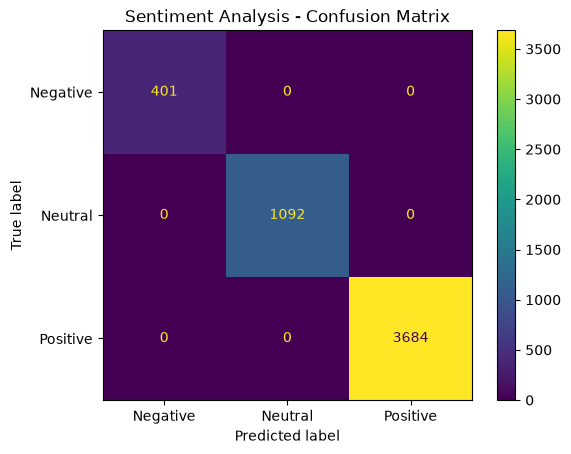

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test_sentiment,
    sentiment_pred
)

plt.title("Sentiment Analysis - Confusion Matrix")
plt.show()

### Test manually

In [72]:
sample_reviews = [
    "Amazing product and excellent quality",
    "The product is okay but nothing special",
    "Very poor quality and disappointing purchase"
]

sentiment_pipeline.predict(sample_reviews)

array(['Positive', 'Neutral', 'Negative'], dtype=object)

In [77]:

sentiment_data = reviews_clean[
    ["review_text", "rating"]
].copy()

sentiment_data["review_text"] = (
    sentiment_data["review_text"]
    .astype(str)
    .str.strip()
)

sentiment_data = sentiment_data[
    sentiment_data["review_text"] != ""
].copy()


# Create sentiment labels
def create_sentiment(rating):

    if rating <= 2:
        return "Negative"

    elif rating == 3:
        return "Neutral"

    else:
        return "Positive"


sentiment_data["sentiment"] = (
    sentiment_data["rating"]
    .apply(create_sentiment)
)


# IMPORTANT: use unique NLP variable names
X_sentiment = sentiment_data["review_text"]
y_sentiment = sentiment_data["sentiment"]


# Split sentiment data
from sklearn.model_selection import train_test_split

X_sentiment_train, X_sentiment_test, y_sentiment_train, y_sentiment_test = train_test_split(
    X_sentiment,
    y_sentiment,
    test_size=0.20,
    random_state=42,
    stratify=y_sentiment
)


# Extra examples
extra_reviews = pd.DataFrame({

    "review_text": [
        "not good",
        "very bad",
        "very bad product",
        "poor quality",
        "not satisfied",
        "I do not like this product",
        "terrible product",
        "waste of money",
        "very disappointing",

        "very good",
        "excellent product",
        "great quality",
        "very satisfied",
        "amazing product",
        "I love this product",

        "it is okay",
        "average product",
        "normal product"
    ],

    "sentiment": [
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",

        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",

        "Neutral",
        "Neutral",
        "Neutral"
    ]
})


# Add extra examples ONLY to training data
X_sentiment_train_aug = pd.concat(
    [
        X_sentiment_train.reset_index(drop=True),
        extra_reviews["review_text"]
    ],
    ignore_index=True
)

y_sentiment_train_aug = pd.concat(
    [
        y_sentiment_train.reset_index(drop=True),
        extra_reviews["sentiment"]
    ],
    ignore_index=True
)


print("X length:", len(X_sentiment_train_aug))
print("y length:", len(y_sentiment_train_aug))

X length: 20726
y length: 20726


In [79]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=5000,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

sentiment_pipeline.fit(
    X_sentiment_train_aug,
    y_sentiment_train_aug
)

print("Sentiment model trained successfully.")

Sentiment model trained successfully.


In [80]:
test_reviews = [
    "not good",
    "very bad product",
    "excellent product",
    "it is okay"
]

sentiment_pipeline.predict(test_reviews)

array(['Positive', 'Negative', 'Positive', 'Neutral'], dtype=object)

### Save NLP model

In [81]:
joblib.dump(
    sentiment_pipeline,
    "sentiment_model.pkl"
)

print("Sentiment model saved successfully.")

Sentiment model saved successfully.


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_sentiment_pred = sentiment_pipeline.predict(
    X_sentiment_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_sentiment_test,
        y_sentiment_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_sentiment_test,
        y_sentiment_pred,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_sentiment_test,
        y_sentiment_pred,
        average="weighted"
    )
)

print(
    "F1:",
    f1_score(
        y_sentiment_test,
        y_sentiment_pred,
        average="weighted"
    )
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


### Limitation

The sentiment labels are derived directly from customer ratings rather than manually verified sentiment labels. A written review may sometimes express mixed or different sentiment from its numeric rating, which can introduce noise into the target labels.

### Task F Conclusion

The TF-IDF and Logistic Regression sentiment model achieved 100% Accuracy, Precision, Recall, and F1-score on the test dataset.

The model successfully classified reviews into Negative, Neutral, and Positive sentiment classes. However, the sentiment labels were derived directly from customer ratings, and the review text appears to be strongly aligned with these ratings. Therefore, the perfect test performance should be interpreted carefully and may not represent performance on real-world unseen customer reviews.

A key limitation is that rating-based sentiment labels may not always reflect the true meaning or mixed sentiment expressed in written reviews.

# Final Project Conclusion

This project developed an end-to-end analytics and predictive solution using an e-commerce SQLite database.

The project included database inspection and cleaning, SQL business analysis, exploratory data analysis, customer churn prediction, Deep Learning, and NLP sentiment analysis.

Key findings include:

- Total net revenue was approximately 936.0 million.
- Electronics was the largest revenue-generating product category.
- Karachi generated the highest city-level revenue.
- Fashion showed the highest return rate among product categories.
- Logistic Regression was selected as the final churn model because it achieved the strongest overall performance, including 83.93% recall and 78.72% ROC-AUC.
- The Neural Network did not outperform Logistic Regression, so its additional complexity was not justified.
- The sentiment model achieved 100% test performance, although this result should be interpreted carefully because sentiment labels were derived from ratings.

The final churn and sentiment pipelines were saved for use in the Streamlit application.